In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

### MLflow setup


In [2]:
import mlflow
import mlflow.pytorch
import os

root_project_path = os.path.abspath("..")
database_path = f"sqlite:///{os.path.join(root_project_path, 'mlflow.db')}"
mlflow.set_tracking_uri(database_path)


In [3]:
mlflow.set_experiment("makemore_file5()_hierarchical")


2026/04/19 20:17:56 INFO mlflow.tracking.fluent: Experiment with name 'makemore_file5()_hierarchical' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:c:/Users/yashs/Documents/Lambton-sem3/Neural '
 'Network/build_makemore/notebook/mlruns/3'), creation_time=1776644276738, experiment_id='3', last_update_time=1776644276738, lifecycle_stage='active', name='makemore_file5()_hierarchical', tags={}, trace_location=None, workspace='default'>

In [4]:

# read in all the words
words = open('../data/names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
s_to_i = {s:i+1 for i,s in enumerate(chars)}
s_to_i['.'] = 0
i_to_s = {i:s for s,i in s_to_i.items()}
vocab_size = len(i_to_s)
print(i_to_s)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [6]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [7]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = s_to_i[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [8]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(i_to_s[ix.item()] for ix in x), '-->', i_to_s[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [9]:
# -----------------
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# --------------------
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# -------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self):
    return [self.weight]

# ---------------------------
class FlattenConsecutive:
  
  def __init__(self, n):
    self.n = n
    
  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out
  
  def parameters(self):
    return []

# -----------------------------
class Sequential:
  
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  
  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]

In [10]:

torch.manual_seed(42); # seed rng for reproducibility

In [11]:
# original network
# n_embd = 10 # the dimensionality of the character embedding vectors
# n_hidden = 300 # the number of neurons in the hidden layer of the MLP
# model = Sequential([
#   Embedding(vocab_size, n_embd),
#   FlattenConsecutive(8), Linear(n_embd * 8, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   Linear(n_hidden, vocab_size),
# ])

# hierarchical network
n_embd = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # the number of neurons in the hidden layer of the MLP
model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

76579


### Training (with MLflow logging)


In [12]:
# same optimization as last time — wrapped with MLflow logging
# also tracks best model by validation loss and saves it as a .pt
# Saves trainable params AND BatchNorm running buffers so inference matches training.

max_steps = 200000
batch_size = 32
lossi = []

log_every = 100
eval_every = 2000

def _collect_bn_buffers():
    # BN running_mean / running_var per BatchNorm1d layer, in layer order.
    # Needed at inference so eval-mode BN uses trained statistics.
    buffers = []
    for layer in model.layers:
        if isinstance(layer, BatchNorm1d):
            buffers.append({
                "running_mean": layer.running_mean.detach().clone(),
                "running_var":  layer.running_var.detach().clone(),
            })
    return buffers

run_id = None
with mlflow.start_run() as run:
    run_id = run.info.run_id

    # hyperparameters
    mlflow.log_param("max_steps", max_steps)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("block_size", block_size)
    mlflow.log_param("n_embd", n_embd)
    mlflow.log_param("n_hidden", n_hidden)
    mlflow.log_param("vocab_size", vocab_size)
    mlflow.log_param("lr_initial", 0.1)
    mlflow.log_param("lr_decayed", 0.01)
    mlflow.log_param("lr_decay_step", 150000)
    mlflow.log_param("n_parameters", sum(p.nelement() for p in parameters))
    mlflow.log_param("log_every", log_every)
    mlflow.log_param("eval_every", eval_every)

    os.makedirs("../weights", exist_ok=True)
    best_weights_path = "../weights/hierarchical_best().pt"
    best_val_loss = float('inf')
    best_step = -1

    for i in range(max_steps):

        # minibatch construct
        ix = torch.randint(0, Xtr.shape[0], (batch_size,))
        Xb, Yb = Xtr[ix], Ytr[ix]

        # forward pass
        logits = model(Xb)
        loss = F.cross_entropy(logits, Yb)

        # backward pass
        for p in parameters:
            p.grad = None
        loss.backward()

        # update
        lr = 0.1 if i < 150000 else 0.01
        for p in parameters:
            p.data += -lr * p.grad

        # track stats
        if i % 10000 == 0:
            print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
        lossi.append(loss.log10().item())

        # log to mlflow
        if i % log_every == 0:
            mlflow.log_metric("loss", loss.item(), step=i)
            mlflow.log_metric("log10_loss", loss.log10().item(), step=i)
            mlflow.log_metric("lr", lr, step=i)

        # validation check — save best model
        if i % eval_every == 0 and i > 0:
            for layer in model.layers:
                layer.training = False
            with torch.no_grad():
                val_logits = model(Xdev)
                val_loss_now = F.cross_entropy(val_logits, Ydev).item()
            for layer in model.layers:
                layer.training = True

            mlflow.log_metric("val_loss", val_loss_now, step=i)

            if val_loss_now < best_val_loss:
                best_val_loss = val_loss_now
                best_step = i
                # Save as dict — trainable params AND BN buffers
                torch.save({
                    "parameters": [p.detach().clone() for p in parameters],
                    "bn_buffers": _collect_bn_buffers(),
                    "metadata": {
                        "n_embd": n_embd,
                        "n_hidden": n_hidden,
                        "block_size": block_size,
                        "vocab_size": vocab_size,
                        "step": i,
                        "val_loss": val_loss_now,
                    },
                }, best_weights_path)
                mlflow.log_metric("best_val_loss", best_val_loss, step=i)

    mlflow.log_artifact(best_weights_path)
    mlflow.log_param("best_weights_file", best_weights_path)
    mlflow.log_param("best_step", best_step)
    print(f"Best val loss: {best_val_loss:.4f} at step {best_step}")


      0/ 200000: 3.3167
  10000/ 200000: 2.0576
  20000/ 200000: 2.0723
  30000/ 200000: 2.5134
  40000/ 200000: 2.1476
  50000/ 200000: 1.7836
  60000/ 200000: 2.2592
  70000/ 200000: 1.9331
  80000/ 200000: 1.6875
  90000/ 200000: 2.0395
 100000/ 200000: 1.7736
 110000/ 200000: 1.9569
 120000/ 200000: 1.7465
 130000/ 200000: 1.8126
 140000/ 200000: 1.7406
 150000/ 200000: 1.7466
 160000/ 200000: 1.8806
 170000/ 200000: 1.6266
 180000/ 200000: 1.6476
 190000/ 200000: 1.8555
Best val loss: 1.9903 at step 180000


### Loss curve


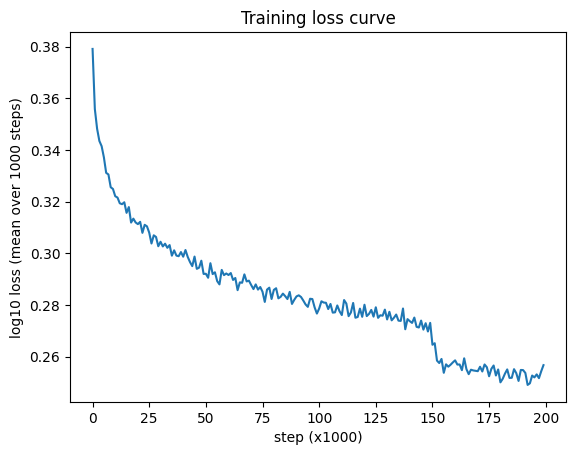

In [13]:
# Loss curve — save and log as artifact, resuming the same run
mlflow.start_run(run_id=run_id)

os.makedirs("../plots", exist_ok=True)
loss_curve_path = "../plots/loss_curve_hierarchical().png"

plt.figure()
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
plt.xlabel("step (x1000)")
plt.ylabel("log10 loss (mean over 1000 steps)")
plt.title("Training loss curve")
plt.savefig(loss_curve_path)
plt.show()

mlflow.log_artifact(loss_curve_path)


In [14]:

# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [15]:
# evaluate the loss — log final train/val as metrics on the same run
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val':   (Xdev, Ydev),
        'test':  (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
    return loss.item()

train_loss = split_loss('train')
val_loss   = split_loss('val')

mlflow.log_metric("final_train_loss", train_loss)
mlflow.log_metric("final_val_loss", val_loss)


train 1.7690284252166748
val 1.9936529397964478


### Performance log

- original (3 character context + 200 hidden neurons, 12K params): train 2.058, val 2.105
- context: 3 -> 8 (22K params): train 1.918, val 2.027
- flat -> hierarchical (22K params): train 1.941, val 2.029
- fix bug in batchnorm: train 1.912, val 2.022
- scale up the network: n_embd 24, n_hidden 128 (76K params): train 1.769, val 1.993

### Load best model (skip retraining)


In [16]:
# Load best model for live demo — restores trainable params AND BN buffers.
# Prerequisites in a fresh kernel: run Cell 0 (imports), the dataset-build cells
# (for block_size, i_to_s, vocab_size), the layer-classes cell, and the model
# instantiation cell. Then run this cell.

best_weights_path = "../weights/hierarchical_best().pt"
checkpoint = torch.load(best_weights_path, map_location='cpu')

# 1. Restore trainable parameters
saved_params = checkpoint["parameters"]
assert len(saved_params) == len(parameters), (
    f"Mismatch: checkpoint has {len(saved_params)} tensors, "
    f"model expects {len(parameters)}. Did the architecture change?"
)
for p, saved in zip(parameters, saved_params):
    p.data = saved.data

# 2. Restore BatchNorm running buffers
saved_bn = checkpoint["bn_buffers"]
bn_layers = [layer for layer in model.layers if isinstance(layer, BatchNorm1d)]
assert len(saved_bn) == len(bn_layers), (
    f"Mismatch: checkpoint has {len(saved_bn)} BN buffers, "
    f"model has {len(bn_layers)} BN layers."
)
for layer, buf in zip(bn_layers, saved_bn):
    layer.running_mean = buf["running_mean"]
    layer.running_var  = buf["running_var"]

# 3. Put all layers into eval mode
for layer in model.layers:
    layer.training = False

meta = checkpoint.get("metadata", {})
print(f"Loaded best model from {best_weights_path}")
if meta:
    print(f"  trained for {meta.get('step', '?')} steps, val_loss={meta.get('val_loss', '?'):.4f}")
print("Model is in eval mode and ready to generate.")


Loaded best model from ../weights/hierarchical_best().pt
  trained for 180000 steps, val_loss=1.9903
Model is in eval mode and ready to generate.


### Sampling (logged to MLflow)


In [17]:
# sample from the model — log every generated name as a text artifact
g = torch.Generator().manual_seed(2147483647)

for k in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break

    sample_text = ''.join(i_to_s[i] for i in out) # decode and print the generated word
    print(sample_text)

    mlflow.log_text(sample_text, f"sample_{k}.txt")

mlflow.end_run()


celia.
loghan.
kimari.
ahnevin.
milianna.
kaysen.
tar.
samiyah.
javari.
mari.
moriella.
ovan.
teda.
kaley.
masideu.
tiavonni.
folup.
hunter.
viah.
ash.
